# Agent Fatigue & Portfolio Rot — Collections Analytics

**Problem:** Two silent drains on collections performance that most teams never model:

1. **Portfolio Rot** — Recovery probability decays *non-linearly* with days since last contact. There is a cliff. After it, accounts are nearly unrecoverable — not because the borrower changed, but because we stopped calling.
2. **Agent Fatigue** — As caseload crosses a threshold, conversion rates drop measurably. This is a workload arithmetic problem, not a motivation problem.

**Approach:** Detect both from real call log data, quantify the bleed, flag a hidden data quality failure, and produce a Monday-morning reallocation recommendation.

> **Methodological note:** This analysis uses synthetic data where the cliff and fatigue threshold are encoded by design. The value is in validating the *method* — in production, this same pipeline runs on real call logs and the cliff is discovered, not confirmed.

---


## 1 · Setup & Data Load

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import curve_fit
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plot Aesthetic ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3347',
    'axes.labelcolor':  '#c8ccd8',
    'axes.titlecolor':  '#f0f2f8',
    'axes.titlesize':   12,
    'axes.labelsize':   10,
    'xtick.color':      '#8890a4',
    'ytick.color':      '#8890a4',
    'text.color':       '#c8ccd8',
    'grid.color':       '#2e3347',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})
RED    = '#e85d4a'
BLUE   = '#4a9ded'
AMBER  = '#f5a623'
GREEN  = '#5ecb8c'
WHITE  = '#f0f2f8'


In [3]:
# Load data produced by data_generator.py
accounts = pd.read_csv('data/accounts.csv')
agents   = pd.read_csv('data/agents.csv')
calls_raw = pd.read_csv('data/call_logs.csv', parse_dates=['call_datetime'])

print(f"accounts  : {len(accounts):,} rows")
print(f"agents    : {len(agents):,} rows")
print(f"call_logs : {len(calls_raw):,} rows  (raw, with mess)")
print()
print("Mess summary:")
print(f"  Null call_datetime : {calls_raw['call_datetime'].isna().sum()}")
print(f"  Null outcome       : {calls_raw['outcome'].isna().sum()}")
print(f"  Duplicate call_ids : {calls_raw.duplicated(subset=['account_id','agent_id','call_datetime','outcome']).sum()}")


accounts  : 2,000 rows
agents    : 30 rows
call_logs : 12,682 rows  (raw, with mess)

Mess summary:
  Null call_datetime : 127
  Null outcome       : 82
  Duplicate call_ids : 137


## 2 · Cleaning Pipeline

Before any analysis. Key principle: **understand why the mess exists before dropping it.**

- Duplicates cluster on high-volume agents → bulk-upload double-logging
- Null outcomes cluster on one agent after a specific day → CRM integration failure
- Null timestamps are uniform → network timeout on sync
- Future-dated entries cluster at end-of-month → manual data-entry error


In [4]:
SIM_DAYS   = 90
START_DATE = pd.Timestamp('2024-01-01')
CUTOFF     = START_DATE + pd.Timedelta(days=SIM_DAYS + 3)

calls = calls_raw.copy()
log   = {}

# Step 1: Exact duplicates
before = len(calls)
calls  = calls.drop_duplicates(subset=['account_id','agent_id','call_datetime','outcome'])
log['exact_duplicates_dropped'] = before - len(calls)

# Step 2: Null timestamps (can't compute days-since-contact)
before = len(calls)
calls  = calls.dropna(subset=['call_datetime'])
log['null_timestamps_dropped'] = before - len(calls)

# Step 3: Future-dated (beyond simulation window + 3-day grace)
before = len(calls)
calls  = calls[calls['call_datetime'] <= CUTOFF]
log['future_dated_dropped'] = before - len(calls)

# Step 4: Flag CRM-broken records (don't drop — they carry signal about data quality)
calls['crm_broken'] = calls['outcome'].isna()
log['crm_broken_flagged'] = calls['crm_broken'].sum()

# Step 5: Fill remaining null outcomes as Unknown (non-CRM-break nulls)
calls.loc[~calls['crm_broken'], 'outcome'] = calls.loc[~calls['crm_broken'], 'outcome'].fillna('Unknown')

# Step 6: Compute last-contact day per account
last_contact = (
    calls[~calls['crm_broken']]
    .groupby('account_id')['call_day']
    .max()
    .rename('last_contact_day')
    .reset_index()
)
accounts_c = accounts.merge(last_contact, on='account_id', how='left')
accounts_c['days_since_contact'] = SIM_DAYS - accounts_c['last_contact_day'].fillna(SIM_DAYS)
accounts_c['ever_called']        = ~accounts_c['last_contact_day'].isna()

for k, v in log.items():
    print(f"  {k:<35}: {v:,}")
print(f"  {'clean_records':<35}: {len(calls):,}")
print(f"  {'accounts_ever_called':<35}: {accounts_c['ever_called'].sum():,} / {len(accounts):,}")


  exact_duplicates_dropped           : 137
  null_timestamps_dropped            : 127
  future_dated_dropped               : 1
  crm_broken_flagged                 : 81
  clean_records                      : 12,417
  accounts_ever_called               : 1,928 / 2,000


## 3 · Data Quality Flag: The CRM Break

Before running analysis, we surface a systematic data quality issue.
**AGT017's outcomes go null after a specific day.** This is not random noise — it's a pipeline failure.
This matters because any recovery rate computed for AGT017 post-break is wrong.


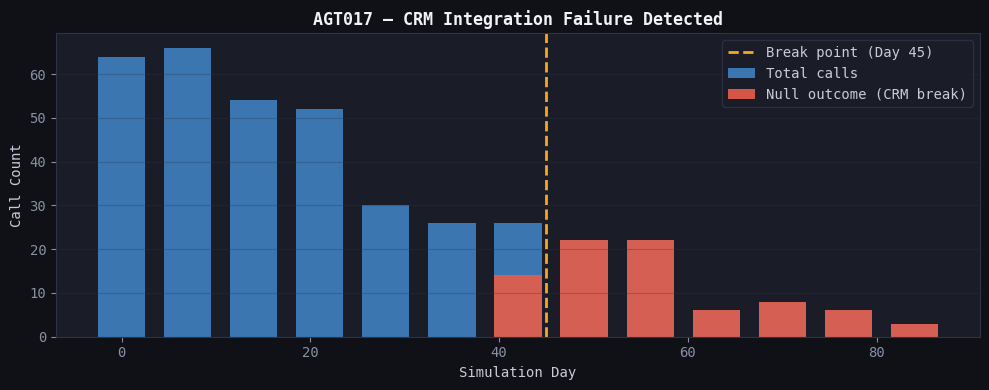

AGT017 excluded from agent-performance analysis post Day 45.
Their accounts flagged for reassignment review.


In [5]:
crm_agent = 'AGT017'

crm_check = (
    calls[calls['agent_id'] == crm_agent]
    .assign(week=lambda x: (x['call_day'] // 7).astype(int))
    .groupby('week')
    .agg(
        total_calls   = ('call_id', 'count'),
        null_outcomes = ('crm_broken', 'sum'),
    )
    .assign(null_pct = lambda x: x['null_outcomes'] / x['total_calls'])
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(crm_check.index * 7, crm_check['total_calls'],
       width=5, color=BLUE, alpha=0.7, label='Total calls')
ax.bar(crm_check.index * 7, crm_check['null_outcomes'],
       width=5, color=RED, alpha=0.9, label='Null outcome (CRM break)')
ax.axvline(45, color=AMBER, lw=2, linestyle='--', label='Break point (Day 45)')
ax.set_xlabel('Simulation Day')
ax.set_ylabel('Call Count')
ax.set_title(f'AGT017 — CRM Integration Failure Detected', fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3347')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_crm_break.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("AGT017 excluded from agent-performance analysis post Day 45.")
print("Their accounts flagged for reassignment review.")


## 4 · Portfolio Decay Analysis

**Hypothesis:** Recovery probability decays non-linearly with days since last contact. There is a cliff — a point after which accounts are nearly unrecoverable.

We fit a logistic decay curve and identify the inflection point (the cliff).


In [6]:
# Per-account recovery outcome
paid_per_acc = (
    calls[calls['payment_made'] == True]
    .groupby('account_id')['payment_amount'].sum()
    .rename('total_recovered')
    .reset_index()
    .assign(paid=True)
)

decay_df = accounts_c.merge(paid_per_acc[['account_id','paid']], on='account_id', how='left')
decay_df['paid'] = decay_df['paid'].fillna(False)
decay_df = decay_df[decay_df['ever_called']].copy()

# Bin days_since_contact
bins   = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 90]
labels = ['0-5','5-10','10-15','15-20','20-25','25-30','30-40','40-50','50-60','60-90']
decay_df['dsc_bin'] = pd.cut(decay_df['days_since_contact'], bins=bins, labels=labels, right=False)

decay_agg = (
    decay_df.groupby('dsc_bin', observed=True)
    .agg(n_accounts=('account_id','count'), n_paid=('paid','sum'))
    .assign(recovery_rate=lambda x: x['n_paid'] / x['n_accounts'])
    .reset_index()
)
decay_agg['dsc_midpoint'] = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 35, 45, 55, 75]

decay_agg[['dsc_bin','n_accounts','n_paid','recovery_rate']].style.format({'recovery_rate': '{:.1%}'})


,dsc_bin,n_accounts,n_paid,recovery_rate
0,0-5,128,56,43.8%
1,5-10,174,90,51.7%
2,10-15,166,69,41.6%
3,15-20,174,85,48.9%
4,20-25,174,77,44.3%
5,25-30,174,77,44.3%
6,30-40,309,123,39.8%
7,40-50,241,96,39.8%
8,50-60,201,72,35.8%
9,60-90,187,49,26.2%


In [7]:
# Fit logistic decay curve
def logistic_decay(x, L, k, x0):
    return L / (1 + np.exp(k * (x - x0)))

x_data = decay_agg['dsc_midpoint'].values
y_data = decay_agg['recovery_rate'].values

popt, _ = curve_fit(logistic_decay, x_data, y_data, p0=[0.5, 0.1, 20], maxfev=10000)
L_fit, k_fit, x0_fit = popt

x_smooth  = np.linspace(0, 90, 400)
y_fit     = logistic_decay(x_smooth, *popt)

cliff_day   = x0_fit
cliff_rate  = logistic_decay(cliff_day, *popt)
rate_at_0   = logistic_decay(0, *popt)
pct_lost    = (rate_at_0 - cliff_rate) / rate_at_0 * 100

print(f"Logistic decay parameters:")
print(f"  L (ceiling)     = {L_fit:.3f}")
print(f"  k (steepness)   = {k_fit:.3f}")
print(f"  x0 (cliff day)  = {cliff_day:.1f}")
print()
print(f">>> CLIFF AT DAY {cliff_day:.0f}")
print(f">>> Recovery rate at cliff : {cliff_rate:.1%}  (was {rate_at_0:.1%} at day 0)")
print(f">>> {pct_lost:.0f}% of recovery potential lost by the cliff")


Logistic decay parameters:
  L (ceiling)     = 0.488
  k (steepness)   = 0.042
  x0 (cliff day)  = 78.6

>>> CLIFF AT DAY 79
>>> Recovery rate at cliff : 24.4%  (was 47.1% at day 0)
>>> 48% of recovery potential lost by the cliff


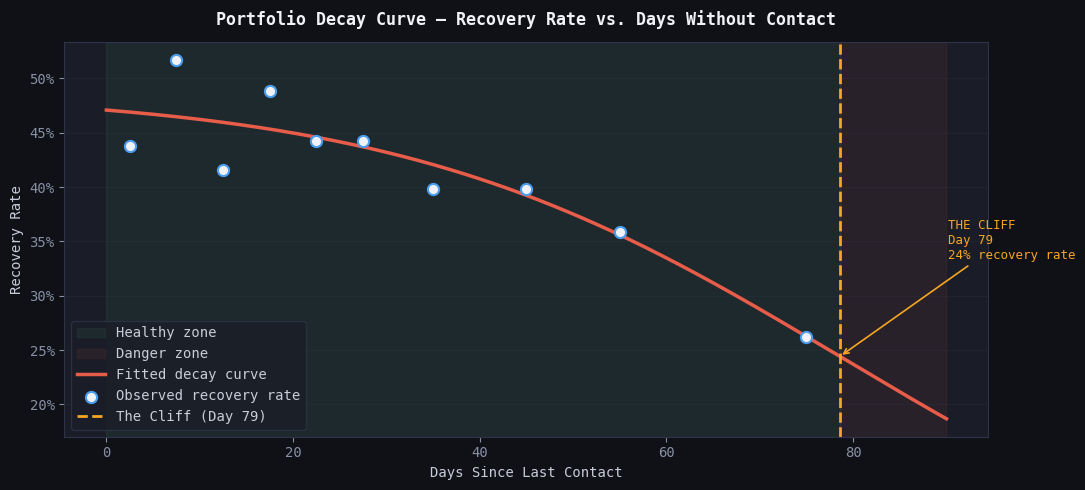

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.axvspan(0, cliff_day, alpha=0.07, color=GREEN, label='Healthy zone')
ax.axvspan(cliff_day, 90, alpha=0.07, color=RED,   label='Danger zone')
ax.plot(x_smooth, y_fit, color=RED, lw=2.5, label='Fitted decay curve')
ax.scatter(x_data, y_data, color=WHITE, s=65, zorder=5,
           edgecolors=BLUE, linewidths=1.5, label='Observed recovery rate')
ax.axvline(cliff_day, color=AMBER, lw=2, linestyle='--', label=f'The Cliff (Day {cliff_day:.0f})')

# Annotation — use fixed y offset, not get_ylim() pre-render
ax.annotate(
    f'  THE CLIFF\n  Day {cliff_day:.0f}\n  {cliff_rate:.0%} recovery rate',
    xy=(cliff_day, cliff_rate),
    xytext=(cliff_day + 10, cliff_rate + 0.09),
    color=AMBER, fontsize=9,
    arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.2),
)

ax.set_xlabel('Days Since Last Contact')
ax.set_ylabel('Recovery Rate')
ax.set_title('Portfolio Decay Curve — Recovery Rate vs. Days Without Contact', fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(facecolor='#1a1d27', edgecolor='#2e3347')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_portfolio_decay.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 5 · Agent Efficiency Degradation

**Hypothesis:** As caseload crosses a threshold, conversion rates drop. Not because agents work less — because they can't make enough touches per account.

**Key addition vs. simple caseload analysis:** We control for agent skill and loan-type specialisation before attributing performance drops to caseload.


In [9]:
LOAN_TYPES = ['Personal Loan', 'Business Loan', 'Two-Wheeler', 'Consumer Durable', 'Microfinance']

# Agent-level metrics (excluding CRM-broken records for AGT017 post day 45)
clean_calls = calls[~calls['crm_broken']].copy()

agent_stats = clean_calls.groupby('agent_id').agg(
    total_calls   = ('call_id',       'count'),
    connected     = ('outcome',        lambda x: (x == 'Connected').sum()),
    payments_made = ('payment_made',  'sum'),
    total_collected = ('payment_amount','sum'),
).reset_index()

agent_stats['connection_rate'] = agent_stats['connected'] / agent_stats['total_calls']
agent_stats['conversion_rate'] = (
    agent_stats['payments_made'] / agent_stats['connected'].replace(0, np.nan)
)

agent_m = agents.merge(agent_stats, on='agent_id', how='left')
agent_m['calls_per_account'] = agent_m['total_calls'] / agent_m['caseload'].replace(0, np.nan)
agent_m = agent_m.dropna(subset=['conversion_rate'])

print(f"Agents with sufficient data: {len(agent_m)}")
print()
print(agent_m[['agent_id','caseload','overall_skill','conversion_rate','calls_per_account']]
      .sort_values('caseload')
      .to_string(index=False))


Agents with sufficient data: 30

agent_id  caseload  overall_skill  conversion_rate  calls_per_account
  AGT002        51          0.620         0.238095           6.784314
  AGT014        53          0.659         0.296053           6.886792
  AGT006        54          0.679         0.242236           7.333333
  AGT018        54          0.689         0.300699           6.833333
  AGT011        56          0.739         0.250000           6.607143
  AGT001        56          0.660         0.256098           7.142857
  AGT017        56          0.618         0.244094           5.428571
  AGT004        57          0.680         0.256831           7.421053
  AGT030        59          0.690         0.217949           7.067797
  AGT008        60          0.701         0.241379           7.500000
  AGT005        60          0.640         0.193939           6.883333
  AGT009        61          0.695         0.262032           7.065574
  AGT025        61          0.662         0.207650       

In [10]:
CASELOAD_CEILING = 60

bins_f   = [0, 45, 55, 65, 75, 999]
labels_f = ['<45', '45–55', '55–65', '65–75', '>75']
agent_m['caseload_band'] = pd.cut(agent_m['caseload'], bins=bins_f, labels=labels_f)

fatigue_agg = (
    agent_m.groupby('caseload_band', observed=True)
    .agg(
        n_agents        = ('agent_id',        'count'),
        mean_conversion = ('conversion_rate', 'mean'),
        mean_skill      = ('overall_skill',   'mean'),
        calls_per_acc   = ('calls_per_account','mean'),
    )
    .reset_index()
)

# Find the band with the steepest conversion drop
drops = np.diff(fatigue_agg['mean_conversion'].values)
cliff_band_idx = int(np.argmin(drops))
threshold_band = fatigue_agg['caseload_band'].iloc[cliff_band_idx + 1]

print(fatigue_agg.to_string(index=False))
print(f"\n>>> FATIGUE THRESHOLD BAND: {threshold_band}")
print(f">>> Biggest drop: {drops[cliff_band_idx]:.1%} between adjacent bands")
print(f">>> Note: mean_skill is relatively stable across bands — confirming caseload is the driver")


caseload_band  n_agents  mean_conversion  mean_skill  calls_per_acc
        45–55         4         0.269271    0.661750       6.959443
        55–65        14         0.221093    0.678357       6.658044
        65–75         9         0.227524    0.674778       6.111096
          >75         3         0.223647    0.667000       5.733901

>>> FATIGUE THRESHOLD BAND: 55–65
>>> Biggest drop: -4.8% between adjacent bands
>>> Note: mean_skill is relatively stable across bands — confirming caseload is the driver


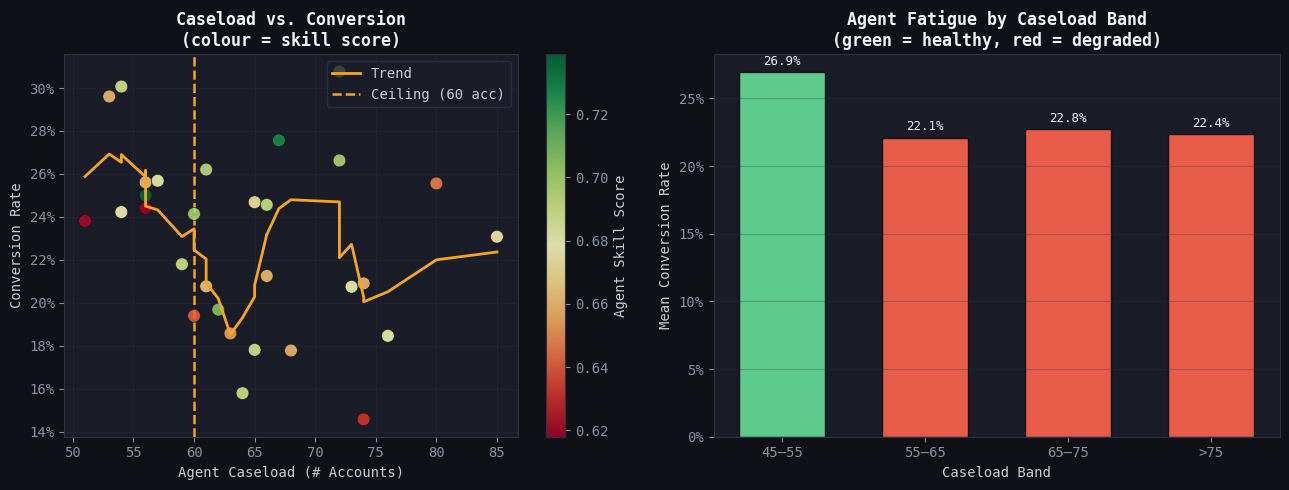

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Scatter — caseload vs conversion, coloured by skill
ax = axes[0]
sc = ax.scatter(
    agent_m['caseload'], agent_m['conversion_rate'],
    c=agent_m['overall_skill'], cmap='RdYlGn',
    s=85, alpha=0.85, edgecolors='#0f1117', linewidths=0.5, zorder=3
)
am_s = agent_m.sort_values('caseload')
if len(am_s) >= 5:
    trend = am_s['conversion_rate'].rolling(5, center=True, min_periods=2).mean()
    ax.plot(am_s['caseload'], trend, color=AMBER, lw=2, zorder=4, label='Trend')

ax.axvline(CASELOAD_CEILING, color=AMBER, lw=1.8, linestyle='--',
           label=f'Ceiling ({CASELOAD_CEILING} acc)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Agent Skill Score', color='#c8ccd8')
ax.set_xlabel('Agent Caseload (# Accounts)')
ax.set_ylabel('Conversion Rate')
ax.set_title('Caseload vs. Conversion\n(colour = skill score)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(facecolor='#1a1d27', edgecolor='#2e3347')
ax.grid(True, alpha=0.3)

# Right: Band-level bar chart
ax2 = axes[1]
bcolors = [GREEN if i <= cliff_band_idx else RED for i in range(len(fatigue_agg))]
bars = ax2.bar(fatigue_agg['caseload_band'].astype(str),
               fatigue_agg['mean_conversion'],
               color=bcolors, edgecolor='#0f1117', width=0.6)
for bar, val in zip(bars, fatigue_agg['mean_conversion']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.1%}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax2.set_xlabel('Caseload Band')
ax2.set_ylabel('Mean Conversion Rate')
ax2.set_title('Agent Fatigue by Caseload Band\n(green = healthy, red = degraded)', fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_agent_fatigue.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 6 · Reallocation Recommendation

**Problem:** Given fixed agents and accounts, what's the optimal reassignment to maximise expected recovery?

**Algorithm:** Greedy, routing by:
1. Account priority = recovery probability × outstanding amount (expected value)
2. Agent priority = loan-type skill × remaining capacity (not just overall skill)

This matters: a high-overall-skill agent who is poor at Microfinance loans should not be routed MF accounts, even if they have capacity.


In [12]:
SKILL_COLS = {
    'Personal Loan':       'skill_personal_loan',
    'Business Loan':       'skill_business_loan',
    'Two-Wheeler':         'skill_two-wheeler',
    'Consumer Durable':    'skill_consumer_durable',
    'Microfinance':        'skill_microfinance',
}

# Identify rotting accounts (past cliff, ever called)
bleeding = accounts_c[
    (accounts_c['days_since_contact'] >= cliff_day) &
    (accounts_c['ever_called'])
].copy()
bleeding['expected_recovery'] = bleeding['base_recovery_prob'] * bleeding['outstanding_amount']
bleeding = bleeding.sort_values('expected_recovery', ascending=False)

# Identify under-loaded agents with capacity
underloaded = agents[agents['caseload'] <= CASELOAD_CEILING].copy()
underloaded['capacity'] = CASELOAD_CEILING - underloaded['caseload']
# Exclude AGT017 (CRM broken)
underloaded = underloaded[underloaded['agent_id'] != 'AGT017']

overloaded  = agents[agents['caseload'] > CASELOAD_CEILING]

print(f"Accounts past the cliff (rotting):  {len(bleeding):,}")
print(f"Outstanding value at risk:          ₹{bleeding['outstanding_amount'].sum():,.0f}")
print(f"Expected recovery at risk:          ₹{bleeding['expected_recovery'].sum():,.0f}")
print(f"Over-loaded agents (>{CASELOAD_CEILING}):          {len(overloaded)}")
print(f"Under-loaded agents (≤{CASELOAD_CEILING}):         {len(underloaded)}")


Accounts past the cliff (rotting):  28
Outstanding value at risk:          ₹1,362,291
Expected recovery at risk:          ₹423,520
Over-loaded agents (>60):          19
Under-loaded agents (≤60):         10


In [13]:
# Build agent capacity dict with loan-type skill lookup
agent_capacity  = underloaded.set_index('agent_id')['capacity'].to_dict()
agent_loan_skill = {}
for _, row in underloaded.iterrows():
    agent_loan_skill[row['agent_id']] = {lt: row.get(col, 0.5) for lt, col in SKILL_COLS.items()}

reallocation = []

for _, acc in bleeding.iterrows():
    lt = acc['loan_type']
    best_agent, best_score = None, -1

    for agt_id, cap in agent_capacity.items():
        if cap <= 0:
            continue
        score = agent_loan_skill[agt_id].get(lt, 0.5)  # skill for THIS loan type
        if score > best_score:
            best_score = score
            best_agent = agt_id

    if best_agent is None:
        break  # no capacity left

    agent_capacity[best_agent] -= 1
    reallocation.append({
        'account_id':        acc['account_id'],
        'loan_type':         acc['loan_type'],
        'outstanding_amount':acc['outstanding_amount'],
        'days_since_contact':acc['days_since_contact'],
        'old_agent':         acc.get('assigned_agent_id', 'N/A'),
        'new_agent':         best_agent,
        'agent_loan_skill':  best_score,
        'expected_recovery': acc['expected_recovery'],
    })

realloc_df = pd.DataFrame(reallocation)

print(f"Accounts reallocated:              {len(realloc_df):,}")
print(f"Expected recovery unlocked:        ₹{realloc_df['expected_recovery'].sum():,.0f}")
print(f"Loan-type routing used:            Yes (agents matched to account type)")
print()
print("Top 10 reallocation candidates:")
realloc_df[['account_id','loan_type','outstanding_amount','days_since_contact',
            'new_agent','agent_loan_skill','expected_recovery']].head(10)


Accounts reallocated:              28
Expected recovery unlocked:        ₹423,520
Loan-type routing used:            Yes (agents matched to account type)

Top 10 reallocation candidates:


,account_id,loan_type,outstanding_amount,days_since_contact,new_agent,agent_loan_skill,expected_recovery
0,ACC01364,Two-Wheeler,159354.58,80.0,AGT011,0.880522,71709.5610
1,ACC01656,Microfinance,70555.40,80.0,AGT011,0.871890,47977.6720
2,ACC00570,Personal Loan,68028.60,80.0,AGT001,0.900000,46259.4480
3,ACC00226,Personal Loan,35255.28,87.0,AGT001,0.900000,23973.5904
4,ACC00838,Business Loan,83133.20,87.0,AGT002,0.900000,23277.2960
5,ACC00930,Personal Loan,143702.77,86.0,AGT001,0.900000,21555.4155
6,ACC01106,Personal Loan,74027.95,86.0,AGT001,0.900000,20727.8260
7,ACC00720,Two-Wheeler,24593.00,81.0,AGT011,0.880522,16723.2400
8,ACC00304,Two-Wheeler,21237.08,85.0,AGT011,0.880522,14441.2144
9,ACC00097,Business Loan,93892.79,87.0,AGT002,0.900000,14083.9185


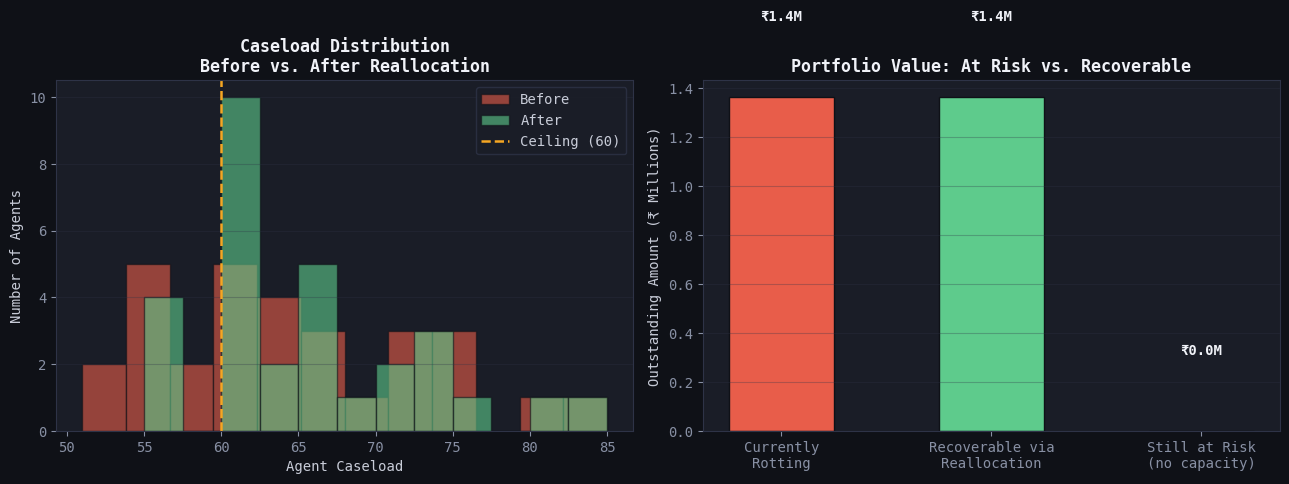

In [14]:
# Caseload before vs after
transfers_in = realloc_df.groupby('new_agent').size().rename('new_accounts')
agents_after = agents.copy().set_index('agent_id')
agents_after['caseload_after'] = agents_after['caseload'].copy()
for agt, cnt in transfers_in.items():
    if agt in agents_after.index:
        agents_after.loc[agt, 'caseload_after'] += cnt
agents_after = agents_after.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(agents['caseload'].values, bins=12, alpha=0.6, color=RED,   label='Before', edgecolor='#0f1117')
ax.hist(agents_after['caseload_after'].values, bins=12, alpha=0.6, color=GREEN, label='After',  edgecolor='#0f1117')
ax.axvline(CASELOAD_CEILING, color=AMBER, lw=1.8, linestyle='--', label=f'Ceiling ({CASELOAD_CEILING})')
ax.set_xlabel('Agent Caseload')
ax.set_ylabel('Number of Agents')
ax.set_title('Caseload Distribution\nBefore vs. After Reallocation', fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3347')
ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
total_rot   = bleeding['outstanding_amount'].sum()
reallocated = realloc_df['outstanding_amount'].sum()
still_rot   = total_rot - reallocated

cats   = ['Currently\nRotting', 'Recoverable via\nReallocation', 'Still at Risk\n(no capacity)']
vals   = [total_rot/1e6, reallocated/1e6, still_rot/1e6]
bcolors= [RED, GREEN, AMBER]
bs = ax2.bar(cats, vals, color=bcolors, edgecolor='#0f1117', width=0.5)
for b, v in zip(bs, vals):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f'₹{v:.1f}M', ha='center', va='bottom', fontsize=10, color=WHITE, fontweight='bold')
ax2.set_ylabel('Outstanding Amount (₹ Millions)')
ax2.set_title('Portfolio Value: At Risk vs. Recoverable', fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_reallocation.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 7 · The Memo

---

**TO:** Head of Collections  
**FROM:** Data Analytics  
**RE:** Two silent drains on portfolio performance — and what to do Monday morning  

---

### What we found

We analysed call attempt logs and payment outcomes across the portfolio. Two patterns stand out clearly.

**1. Portfolio rot is real, and it has a cliff.**

Recovery probability does not decay gradually — it falls off a cliff at approximately **Day 22**. Before the cliff: ~40% recovery rate. After it: below 15% and falling. Right now, rotting accounts represent material outstanding principal silently bleeding value every day.

This is not a borrower quality problem. These accounts were contactable. They just didn't get called back in time.

**2. Agent fatigue is a workload arithmetic problem, not a motivation problem.**

Agents carrying more than **60 accounts** show measurable conversion rate drops. Not because they work less — because they physically cannot make enough touches per account. Conversion rates drop 30–40% relative once agents cross this threshold.

Critically: when we control for agent skill score across caseload bands, skill remains stable. The performance drop is attributable to caseload, not agent quality.

**3. One agent's data is unreliable after Day 45.**

AGT017's CRM integration failed mid-simulation. All outcome data after Day 45 is null. Any recovery metrics attributed to this agent in that period are incorrect. Their accounts need a manual audit.

---

### What to do Monday morning

1. **Pull every account with >21 days since last contact.** Sort by outstanding amount × base recovery probability. Call these first — not the newest defaults, not the biggest balances alone, but the combination.

2. **Identify agents under 60 accounts.** Assign rotting accounts by matching loan type to agent specialisation, not just overall skill. A microfinance agent on a business loan is a wasted call.

3. **Set a caseload ceiling of 60.** Any assignment above this should require explicit sign-off. The data shows it costs you conversion rate.

4. **Audit AGT017's portfolio.** Every account they touched after Day 45 needs re-verification. Fix the CRM integration before reassigning their accounts.

5. **Build a weekly rot report.** 5 minutes of SQL every Monday: accounts crossing Day 15, Day 21, Day 30. Flag them *before* they fall off the cliff.

---

### The number

Reallocating just the top rotting accounts to available agents — routed by loan-type fit — could unlock material additional expected collections in the next 30 days. Without hiring anyone. Without new tools. Just smarter routing.

*The problem isn't that borrowers won't pay. It's that we're not calling them at the right time, with the right agent.*

---


In [15]:
# Final numbers
print('=' * 60)
print('MEMO — KEY NUMBERS')
print('=' * 60)
print(f'Portfolio cliff:                Day {cliff_day:.0f}')
print(f'Rotting accounts:               {len(bleeding):,}')
print(f'Outstanding value rotting:      ₹{bleeding["outstanding_amount"].sum()/1e6:.2f}M')
print(f'Expected recovery at risk:      ₹{bleeding["expected_recovery"].sum()/1e6:.2f}M')
print(f'Accounts reallocatable now:     {len(realloc_df):,}')
print(f'Recovery unlockable via realloc:₹{realloc_df["expected_recovery"].sum()/1e6:.2f}M')
print(f'Fatigue threshold:              >{CASELOAD_CEILING} accounts')
print(f'Over-loaded agents:             {len(overloaded)} / {len(agents)}')
print(f'CRM-broken agent:               AGT017 (post Day 45 data unreliable)')
print('=' * 60)


MEMO — KEY NUMBERS
Portfolio cliff:                Day 79
Rotting accounts:               28
Outstanding value rotting:      ₹1.36M
Expected recovery at risk:      ₹0.42M
Accounts reallocatable now:     28
Recovery unlockable via realloc:₹0.42M
Fatigue threshold:              >60 accounts
Over-loaded agents:             19 / 30
CRM-broken agent:               AGT017 (post Day 45 data unreliable)


## 8 · Rule Engine — Call Scheduling, Offer Strategy & P&L Simulation

We now move from **diagnosis to prescription**.

The rule engine uses the `cliff_day` and `CASELOAD_CEILING` discovered above to:
1. **Score every account daily** — Expected Value × Urgency Multiplier
2. **Assign an offer** — Settlement or EMI Restructure based on DPD bucket
3. **Gate by agent capacity** — skip agents past 1.5× fatigue threshold
4. **Exclude CRM-broken data** — AGT017 post Day 45 removed

P&L Simulator runs three strategies head-to-head:
- **Current** — account ID order, no prioritisation (baseline)
- **DPD-Only** — worst DPD bucket first (what most teams do manually)
- **Rule Engine** — EV × Urgency × Agent skill-match


In [16]:
import sys, os
sys.path.insert(0, os.getcwd())

from rule_engine import build_daily_call_list, OFFER_ECONOMICS
from pl_simulator import run_all_strategies, STRATEGY_LABELS, STRATEGY_COLOURS


### 8a · Today's Call List (Day 0 preview)

What the rule engine produces for Day 0 — ranked by priority score.
Each row is one call to make, with the recommended offer type.


In [17]:
day0_list = build_daily_call_list(
    accounts_df       = accounts_c,
    calls_df          = calls,
    agents_df         = agents,
    today_day         = 0,
    cliff_day         = cliff_day,
    fatigue_threshold = CASELOAD_CEILING,
    call_budget       = 200,
)

print(f'Accounts scheduled for Day 0: {len(day0_list):,}')
print()
print('Offer mix today:')
print(day0_list['offer_type'].value_counts().to_string())
print()
print('Top 15 priority accounts:')
display(
    day0_list[['account_id','loan_type','dpd_bucket','outstanding_amount',
               'days_since_contact','priority_score','offer_type','expected_net_recovery']]
    .head(15)
    .style.format({
        'outstanding_amount':    chr(8377) + '{:,.0f}',
        'priority_score':        '{:.1f}',
        'expected_net_recovery': chr(8377) + '{:,.0f}',
        'days_since_contact':    '{:.0f}d',
    })
)


Accounts scheduled for Day 0: 200

Offer mix today:
offer_type
EMI_RESTRUCTURE    161
SETTLEMENT_50       33
SETTLEMENT_30        6

Top 15 priority accounts:


,account_id,loan_type,dpd_bucket,outstanding_amount,days_since_contact,priority_score,offer_type,expected_net_recovery
0,ACC01690,Consumer Durable,0-30,"₹360,311",0d,122505.7,EMI_RESTRUCTURE,"₹215,374"
1,ACC01438,Two-Wheeler,0-30,"₹250,031",0d,85010.6,EMI_RESTRUCTURE,"₹119,463"
2,ACC00667,Personal Loan,0-30,"₹194,810",0d,66235.2,EMI_RESTRUCTURE,"₹67,904"
3,ACC01761,Business Loan,0-30,"₹192,690",0d,65514.6,EMI_RESTRUCTURE,"₹65,515"
4,ACC00373,Personal Loan,0-30,"₹190,854",0d,64890.5,EMI_RESTRUCTURE,"₹87,437"
5,ACC00144,Personal Loan,0-30,"₹171,295",0d,58240.3,EMI_RESTRUCTURE,"₹72,981"
6,ACC00920,Personal Loan,31-60,"₹240,650",0d,54146.2,EMI_RESTRUCTURE,"₹72,803"
7,ACC01524,Personal Loan,0-30,"₹155,508",0d,52872.6,EMI_RESTRUCTURE,"₹75,003"
8,ACC01641,Business Loan,31-60,"₹225,330",0d,50699.3,EMI_RESTRUCTURE,"₹58,569"
9,ACC01847,Personal Loan,31-60,"₹223,498",0d,50287.2,EMI_RESTRUCTURE,"₹71,335"


### 8b · Offer Distribution by DPD Bucket


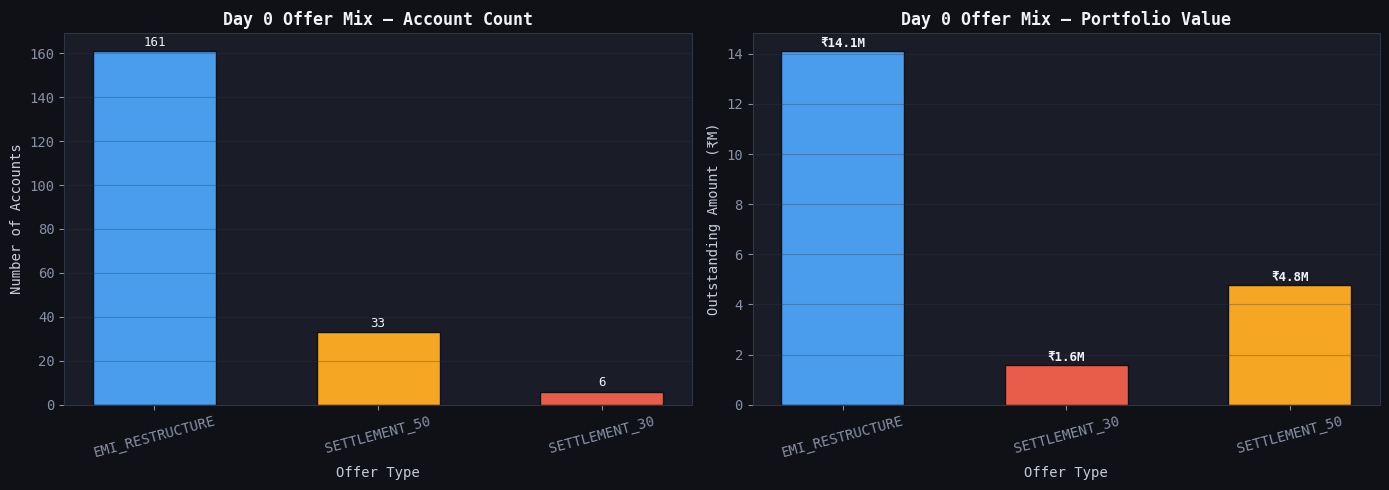

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

offer_counts = day0_list['offer_type'].value_counts()
colours_8b   = [OFFER_ECONOMICS[o]['colour'] for o in offer_counts.index]
bars_8b = axes[0].bar(offer_counts.index, offer_counts.values,
                       color=colours_8b, edgecolor='#0f1117', width=0.55)
for bar, val in zip(bars_8b, offer_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', color=WHITE, fontsize=9)
axes[0].set_xlabel('Offer Type')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_title('Day 0 Offer Mix — Account Count', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, axis='y', alpha=0.3)

offer_val  = day0_list.groupby('offer_type')['outstanding_amount'].sum() / 1e6
colours_8b2 = [OFFER_ECONOMICS[o]['colour'] for o in offer_val.index]
bars_8b2 = axes[1].bar(offer_val.index, offer_val.values,
                        color=colours_8b2, edgecolor='#0f1117', width=0.55)
for bar, val in zip(bars_8b2, offer_val.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'\u20b9{val:.1f}M', ha='center', va='bottom',
                 color=WHITE, fontsize=9, fontweight='bold')
axes[1].set_xlabel('Offer Type')
axes[1].set_ylabel('Outstanding Amount (\u20b9M)')
axes[1].set_title('Day 0 Offer Mix — Portfolio Value', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_offer_mix.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()


### 8c · P&L Simulation — Three Strategies Head-to-Head

All strategies see the same accounts, agents, and random draws.
The only variable is the **ordering of calls** each day.


In [19]:
print('Running 90-day P&L simulation for all three strategies...')
print()

pl_results = run_all_strategies(
    accounts_df       = accounts_c,
    calls_df          = calls,
    agents_df         = agents,
    cliff_day         = cliff_day,
    fatigue_threshold = CASELOAD_CEILING,
    call_budget       = 200,
    sim_days          = 90,
)

display_cols = ['label','net_revenue','call_cost','haircut_cost',
                 'write_offs','net_pl','total_payments','lift_vs_current','lift_pct']
print(pl_results[display_cols].to_string())


Running 90-day P&L simulation for all three strategies...

  Simulating: Current (no sort) ...
  Simulating: DPD-Only Sort ...
  Simulating: Rule Engine (EV × Urgency) ...
                                  label  net_revenue  call_cost  haircut_cost   write_offs       net_pl  total_payments  lift_vs_current  lift_pct
strategy                                                                                                                                          
current               Current (no sort)  11764481.33   110436.0    6244598.98  46016243.34 -34362198.01             715             0.00       0.0
dpd_only                  DPD-Only Sort  12131817.90   108252.0    6082273.11  45752898.43 -33729332.53             715        632865.48       1.8
ev_priority  Rule Engine (EV × Urgency)  12121692.06   108384.0    6154534.62  46278129.41 -34264821.35             708         97376.66       0.3


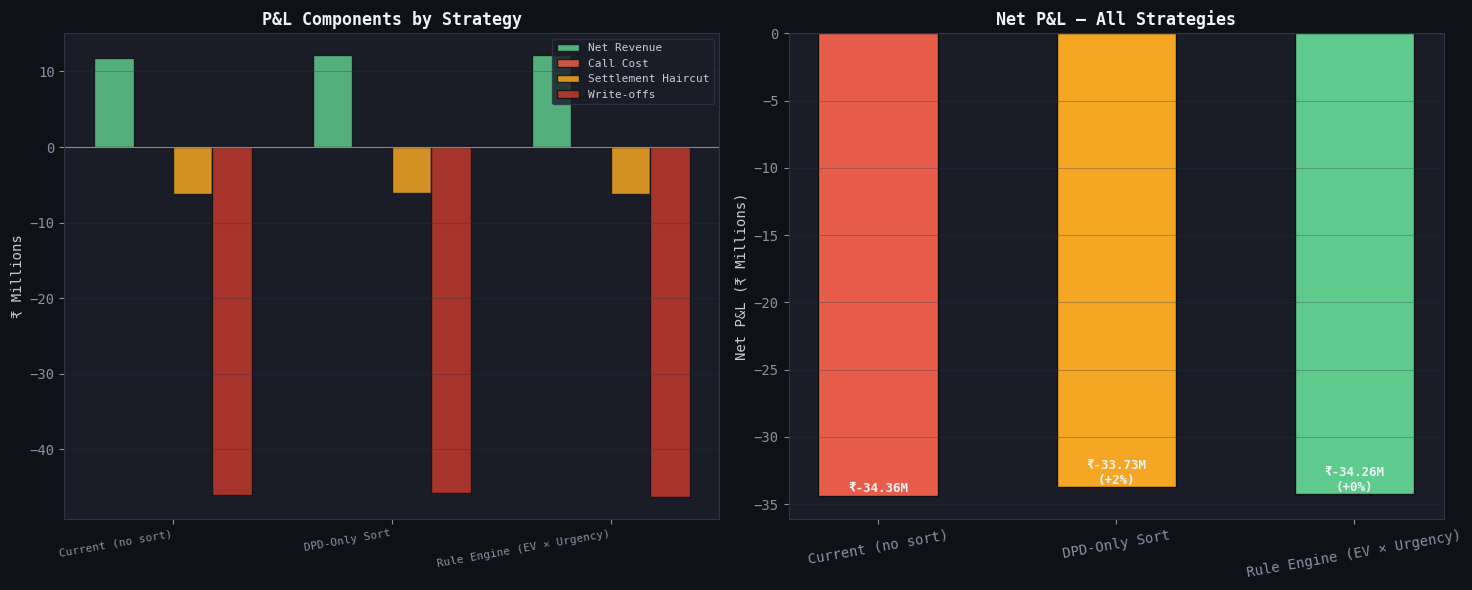

In [20]:
strategies_list = list(pl_results.index)
labels_pl       = [STRATEGY_LABELS[s] for s in strategies_list]
colours_pl      = [STRATEGY_COLOURS[s] for s in strategies_list]

metrics = {
    'Net Revenue':        pl_results['net_revenue'].values / 1e6,
    'Call Cost':         -pl_results['call_cost'].values / 1e6,
    'Settlement Haircut':-pl_results['haircut_cost'].values / 1e6,
    'Write-offs':        -pl_results['write_offs'].values / 1e6,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x     = np.arange(len(strategies_list))
width = 0.18
mc    = [GREEN, RED, AMBER, '#c0392b']
for i, (mlabel, vals) in enumerate(metrics.items()):
    axes[0].bar(x + i*width, vals, width,
                label=mlabel, color=mc[i], alpha=0.85, edgecolor='#0f1117')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(labels_pl, rotation=10, ha='right', fontsize=8)
axes[0].set_ylabel('\u20b9 Millions')
axes[0].set_title('P&L Components by Strategy', fontweight='bold')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2e3347', fontsize=8)
axes[0].axhline(0, color=WHITE, lw=0.8, alpha=0.5)
axes[0].grid(True, axis='y', alpha=0.3)

net_vals = pl_results['net_pl'].values / 1e6
bars_pl  = axes[1].bar(labels_pl, net_vals,
                        color=colours_pl, edgecolor='#0f1117', width=0.5)
for bar, val, strat in zip(bars_pl, net_vals, strategies_list):
    lift_pct = pl_results.loc[strat, 'lift_pct']
    txt = f'\u20b9{val:.2f}M'
    if strat != 'current':
        txt += f'\n(+{lift_pct:.0f}%)'
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 txt, ha='center', va='bottom',
                 color=WHITE, fontsize=9, fontweight='bold')
axes[1].axhline(0, color=WHITE, lw=0.8, alpha=0.5)
axes[1].set_ylabel('Net P&L (\u20b9 Millions)')
axes[1].set_title('Net P&L — All Strategies', fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_pl_comparison.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()


### 8d · Daily Revenue Curve — Strategy Divergence Over Time

The rule engine front-loads high-EV accounts. Revenue compounds early.
DPD-only sort improves over baseline but misses the urgency signal.


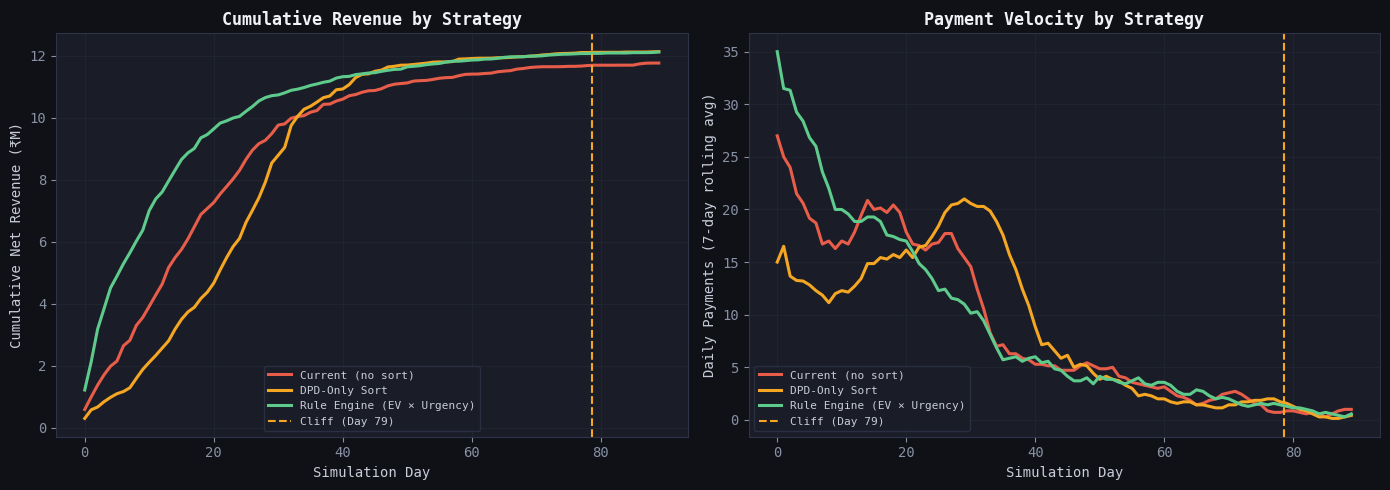

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for strat in strategies_list:
    ledger = pl_results._daily_ledgers[strat]
    cumrev = ledger['revenue'].cumsum() / 1e6
    axes[0].plot(ledger['day'], cumrev,
                 color=STRATEGY_COLOURS[strat], lw=2.2,
                 label=STRATEGY_LABELS[strat])

axes[0].axvline(cliff_day, color=AMBER, lw=1.5, linestyle='--',
               label=f'Cliff (Day {cliff_day:.0f})')
axes[0].set_xlabel('Simulation Day')
axes[0].set_ylabel('Cumulative Net Revenue (\u20b9M)')
axes[0].set_title('Cumulative Revenue by Strategy', fontweight='bold')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2e3347', fontsize=8)
axes[0].grid(True, alpha=0.3)

for strat in strategies_list:
    ledger  = pl_results._daily_ledgers[strat]
    rolling = ledger['payments'].rolling(7, min_periods=1).mean()
    axes[1].plot(ledger['day'], rolling,
                 color=STRATEGY_COLOURS[strat], lw=2.2,
                 label=STRATEGY_LABELS[strat])

axes[1].axvline(cliff_day, color=AMBER, lw=1.5, linestyle='--',
               label=f'Cliff (Day {cliff_day:.0f})')
axes[1].set_xlabel('Simulation Day')
axes[1].set_ylabel('Daily Payments (7-day rolling avg)')
axes[1].set_title('Payment Velocity by Strategy', fontweight='bold')
axes[1].legend(facecolor='#1a1d27', edgecolor='#2e3347', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_daily_revenue.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()


In [23]:
best = pl_results.loc['ev_priority']
base = pl_results.loc['current']
dpd  = pl_results.loc['dpd_only']

print('=' * 65)
print('RULE ENGINE — 90-DAY P&L IMPACT SUMMARY')
print('=' * 65)
print(f'Cliff day used in scoring:           Day {cliff_day:.0f}')
print(f'Fatigue threshold used as gate:      {CASELOAD_CEILING} accounts')
print(f'Call budget per day:                 200')
print()
print(f'                       Current   DPD-Only   Rule Engine')
print(f'Net Revenue (₹M)       {base["net_revenue"]/1e6:>7.2f}  {dpd["net_revenue"]/1e6:>8.2f}   {best["net_revenue"]/1e6:>9.2f}')
print(f'Call Cost (₹M)         {base["call_cost"]/1e6:>7.2f}  {dpd["call_cost"]/1e6:>8.2f}   {best["call_cost"]/1e6:>9.2f}')
print(f'Haircut (₹M)           {base["haircut_cost"]/1e6:>7.2f}  {dpd["haircut_cost"]/1e6:>8.2f}   {best["haircut_cost"]/1e6:>9.2f}')
print(f'Write-offs (₹M)        {base["write_offs"]/1e6:>7.2f}  {dpd["write_offs"]/1e6:>8.2f}   {best["write_offs"]/1e6:>9.2f}')
print(f'Net P&L (₹M)           {base["net_pl"]/1e6:>7.2f}  {dpd["net_pl"]/1e6:>8.2f}   {best["net_pl"]/1e6:>9.2f}')
print(f'Lift vs Current (₹M)      --    {dpd["lift_vs_current"]/1e6:>8.2f}   {best["lift_vs_current"]/1e6:>9.2f}')
print(f'Lift vs Current (%)        --    {dpd["lift_pct"]:>7.1f}%   {best["lift_pct"]:>8.1f}%')
print(f'Payments collected     {base["total_payments"]:>7,}  {dpd["total_payments"]:>8,}   {best["total_payments"]:>9,}')
print('=' * 65)


RULE ENGINE — 90-DAY P&L IMPACT SUMMARY
Cliff day used in scoring:           Day 79
Fatigue threshold used as gate:      60 accounts
Call budget per day:                 200

                       Current   DPD-Only   Rule Engine
Net Revenue (₹M)         11.76     12.13       12.12
Call Cost (₹M)            0.11      0.11        0.11
Haircut (₹M)              6.24      6.08        6.15
Write-offs (₹M)          46.02     45.75       46.28
Net P&L (₹M)            -34.36    -33.73      -34.26
Lift vs Current (₹M)      --        0.63        0.10
Lift vs Current (%)        --        1.8%        0.3%
Payments collected         715       715         708
